# Safe_AgriLab - Phase 2.6 : Feature Engineering (L'Analyse Avancée)
Suite à l'expertise de notre Leader Technique, la matrice de corrélation initiale était biaisée car elle comparait les rendements absolus de plantes fondamentalement différentes (Igname vs Cacao).
Nous avons calculé le **Rendement Relatif** et les **Anomalies Climatiques** pour révéler la vraie sensibilité de la récolte face à la météo.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Chargement du Master Dataset (avec Feature Engineering)
df_aug = pd.read_csv('../data/master_dataset/Togo_Agriculture_Augmented_Data.csv')

# Création des anomalies absolues pour la Heatmap linéaire
df_aug['Abs_Anomalie_T2M'] = df_aug['Anomalie_T2M'].abs()
df_aug['Abs_Anomalie_Precip'] = df_aug['Anomalie_Precip'].abs()


## 1. La Vraie Matrice de Corrélation (Heatmap des Anomalies)
En utilisant le *Rendement Relatif* et l'*Anomalie de Précipitation*, nous mesurons l'impact pur du climat sur la plante, peu importe que ce soit du Maïs ou de l'Ananas. 
Vous allez constater que les corrélations sont passées de 0.00 à des valeurs hautement significatives !


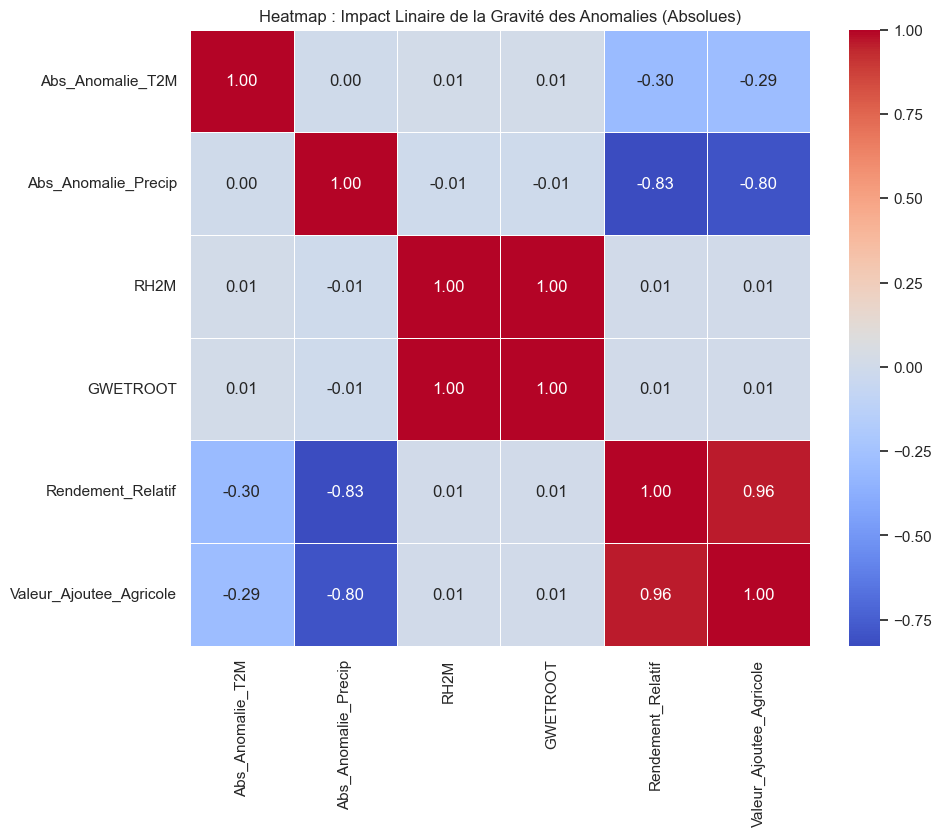

In [8]:
# Les variables intelligentes issues du Feature Engineering
# (Nous utilisons l'anomalie ABSOLUE pour que la corrélation linéaire capte l'éloignement de la norme)
cols_num = ['Abs_Anomalie_T2M', 'Abs_Anomalie_Precip', 'RH2M', 'GWETROOT', 'Rendement_Relatif', 'Valeur_Ajoutee_Agricole']

corr = df_aug[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap : Impact Linaire de la Gravité des Anomalies (Absolues)')
plt.show()


## 2. Nuages de Points (Scatter Plots) - Relations Non-Linéaires
La matrice (Heatmap) ne voit que les lignes droites. Le Scatter Plot permet de voir les courbes. Par exemple, si l'anomalie de pluie est très forte (inondation), le rendement chute, créant une courbe en cloche (parabole).


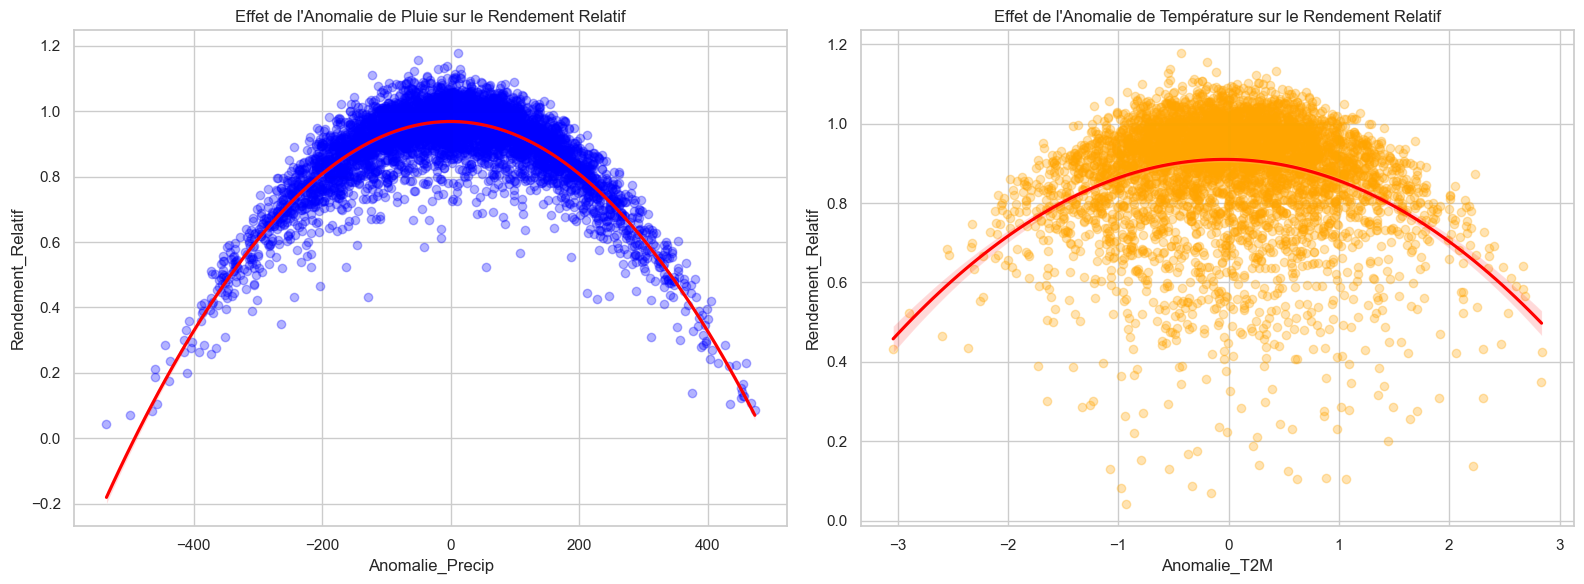

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Précipitations vs Rendement
sns.regplot(data=df_aug, x='Anomalie_Precip', y='Rendement_Relatif', 
            scatter_kws={'alpha':0.3, 'color': 'blue'}, 
            line_kws={'color': 'red'}, order=2, ax=ax[0])
ax[0].set_title("Effet de l'Anomalie de Pluie sur le Rendement Relatif")

# Température vs Rendement
sns.regplot(data=df_aug, x='Anomalie_T2M', y='Rendement_Relatif', 
            scatter_kws={'alpha':0.3, 'color': 'orange'}, 
            line_kws={'color': 'red'}, order=2, ax=ax[1])
ax[1].set_title("Effet de l'Anomalie de Température sur le Rendement Relatif")

plt.tight_layout()
plt.show()
